# Real-time REM detection on the Walch (2019) data

A walk-through of the pipeline on the dataset, using the project modules
(`dataset`, `features`, `module`, `splits`, `evaluate`):

1. the raw wearable signals and PSG labels,
2. the causal features,
3. the real-time (look-ahead) check,
4. leave-one-subject-out evaluation,
5. the baseline score.

Feature extraction lives in `features.py`; `module.py` holds the model.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

import features, splits
from dataset import load_records, REM
from module import build_model

records = load_records()
n_scored = sum(int(r.scored_mask.sum()) for r in records)
n_rem = sum(int((r.stage == REM).sum()) for r in records)
print(f"{len(records)} subjects | {n_scored} scored 30s epochs | "
      f"REM prevalence {100 * n_rem / n_scored:.1f}%")

def rem_spans(r):
    '''Contiguous REM intervals (in hours) for shading plots.'''
    flag = (r.stage == REM).astype(int)
    d = np.diff(flag, prepend=0, append=0)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    h = r.epoch_time / 3600
    return [(h[s], h[min(e, len(h) - 1)]) for s, e in zip(starts, ends)]

['/Users/mustaf/Desktop/realtime-sleep-staging/data/4426783_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/5498603_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/1455390_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/7749105_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/8692923_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/8258170_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/1360686_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/781756_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/8686948_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/759667_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/2598705_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/9618981_labeled_sleep.txt', '/Users/mustaf/Desktop/realtime-sleep-staging/data/99

31 subjects | 26773 scored 30s epochs | REM prevalence 22.0%


## 1. The data

Each subject is one night: heart rate (~0.2 Hz) and triaxial accelerometer
(~30 Hz) from an Apple Watch, with a polysomnography hypnogram at 30 s resolution.
One subject's raw streams, REM periods shaded.

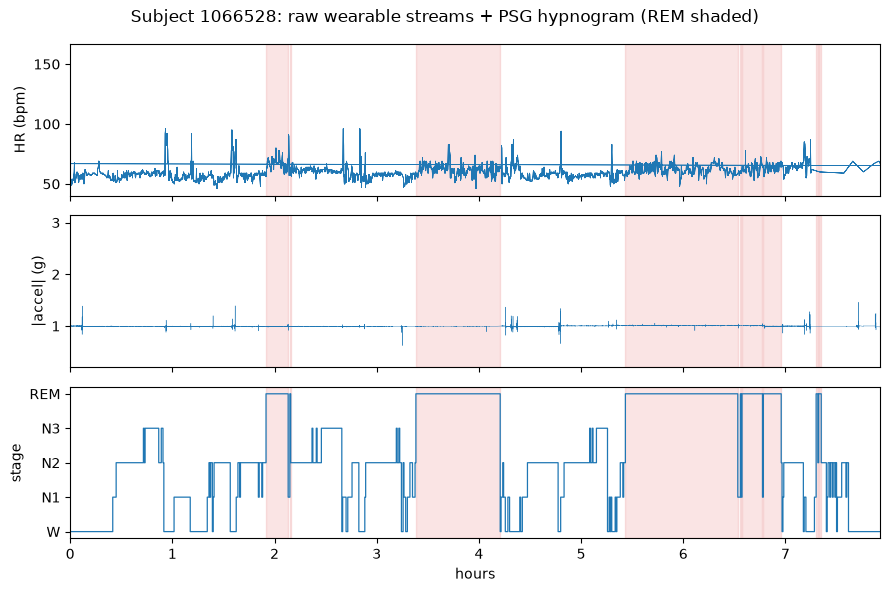

In [2]:
r = records[0]
mag = np.linalg.norm(r.motion, axis=1)
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
ax[0].plot(r.hr_time / 3600, r.hr, lw=0.5); ax[0].set_ylabel("HR (bpm)")
ax[0].set_xlim(0, r.epoch_time.max() / 3600)
ax[1].plot(r.motion_time[::50] / 3600, mag[::50], lw=0.3); ax[1].set_ylabel("|accel| (g)")
ax[2].step(r.epoch_time / 3600, r.stage, where="post", lw=0.9)
ax[2].set_yticks([0, 1, 2, 3, 4]); ax[2].set_yticklabels(["W", "N1", "N2", "N3", "REM"])
ax[2].set_ylabel("stage"); ax[2].set_xlabel("hours")
for a in ax:
    for s, e in rem_spans(r): a.axvspan(s, e, color="tab:red", alpha=0.12)
fig.suptitle(f"Subject {r.subject_id}: raw wearable streams + PSG hypnogram (REM shaded)")
plt.tight_layout(); plt.show()

## 2. Features

`features.featurize` turns the raw streams into one row per epoch: smoothed heart
rate, ActiGraph activity counts (via `agcounts`), and time-of-night, each from
samples at or before the end of that epoch. The features shift during the shaded
REM periods.

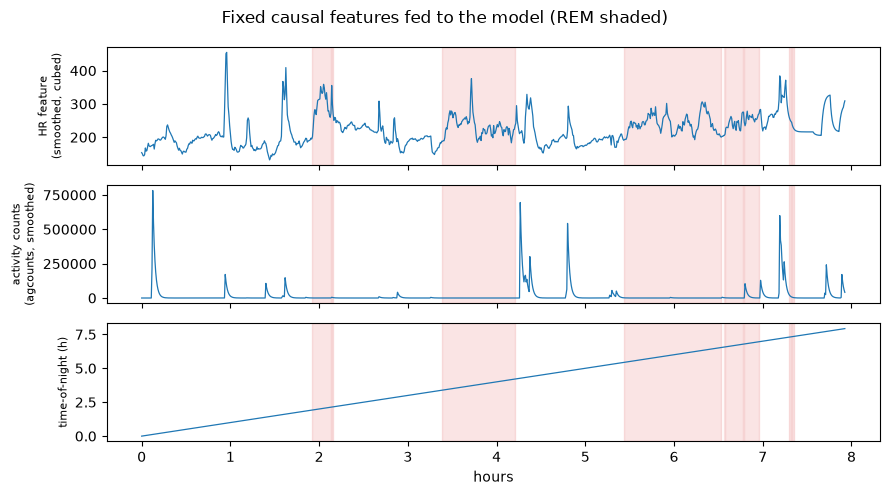

feature matrix shape (epochs x features): (952, 3)


In [3]:
X_one = features.featurize(r)
names = ["HR feature\n(smoothed, cubed)", "activity counts\n(agcounts, smoothed)", "time-of-night (h)"]
fig, ax = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for k in range(3):
    ax[k].plot(r.epoch_time / 3600, X_one[:, k], lw=0.9)
    ax[k].set_ylabel(names[k], fontsize=8)
    for s, e in rem_spans(r): ax[k].axvspan(s, e, color="tab:red", alpha=0.12)
ax[-1].set_xlabel("hours")
fig.suptitle("Fixed causal features fed to the model (REM shaded)")
plt.tight_layout(); plt.show()
print("feature matrix shape (epochs x features):", X_one.shape)

## 3. Real-time (look-ahead) check

A live watch scores each epoch using only data up to that moment. `evaluate.py`
checks this every fold with `_predictions_are_causal`: at several cut points the
first-k predictions must be unchanged when later epochs are removed and when their
content is altered. Below, a causal model passes and a model that reads one epoch
ahead does not.

In [4]:
from evaluate import _predictions_are_causal

X, y, groups = splits.make_dataset(records)     # fixed causal features for every epoch
train_idx, test_idx = next(splits.cross_validator().split(X, y, groups=groups))
model = build_model().fit(X[train_idx], y[train_idx])
X_test = X[test_idx]
print("real-time (causal) model passes the guard :",
      _predictions_are_causal(model, X_test, model.predict(X_test)))

class LookAheadModel:               # cheats: labels epoch i using epoch i+1
    def predict(self, Xa):
        nxt = np.r_[Xa[1:, 0], Xa[-1, 0]]
        return (nxt > 0.5).astype(int)

cheat = LookAheadModel()
print("look-ahead (cheating) model passes the guard:",
      _predictions_are_causal(cheat, X_test, cheat.predict(X_test)))

/Users/mustaf/Desktop/realtime-sleep-staging/.venv/lib/python3.12/site-packages/agcounts/extract.py:347: RuntimeWarning: invalid value encountered in cast
  return counts.astype(int)


real-time (causal) model passes the guard : True
look-ahead (cheating) model passes the guard: False


## 4. Leave-one-subject-out

Epochs from one sleeper are correlated, so testing on a subject you trained on
inflates the score. `splits` groups epochs by subject and uses scikit-learn's
`LeaveOneGroupOut`: each subject is the test set once and never appears in its own
training fold.

In [5]:
cv = splits.cross_validator()
n_folds = cv.get_n_splits(groups=groups)
disjoint = all(set(groups[tr]).isdisjoint(set(groups[te])) for tr, te in cv.split(X, y, groups=groups))
print(f"{n_folds} folds | every subject held out once | train/test subject-disjoint: {disjoint}")
print(f"feature matrix: {X.shape[0]} epochs x {X.shape[1]} fixed features")

31 folds | every subject held out once | train/test subject-disjoint: True
feature matrix: 26773 epochs x 3 fixed features


## 5. Baseline

The leave-one-subject-out loop from `evaluate.py`: for each fold, train on all but
one subject, predict the held-out subject, score REM F1 on that subject, and
average across subjects (mean ± SEM). For reference, the paper reports about 70%
accuracy, 57% REM recall, and 34% REM precision. (Takes ~1-2 min.)

              precision    recall  f1-score   support

         REM       0.28      0.58      0.38      5884

   micro avg       0.28      0.58      0.38      5884
   macro avg       0.28      0.58      0.38      5884
weighted avg       0.28      0.58      0.38      5884

per-subject mean REM F1 (the metric Weco maximizes): 0.3411 +/- 0.0283 SEM  over 31 subjects


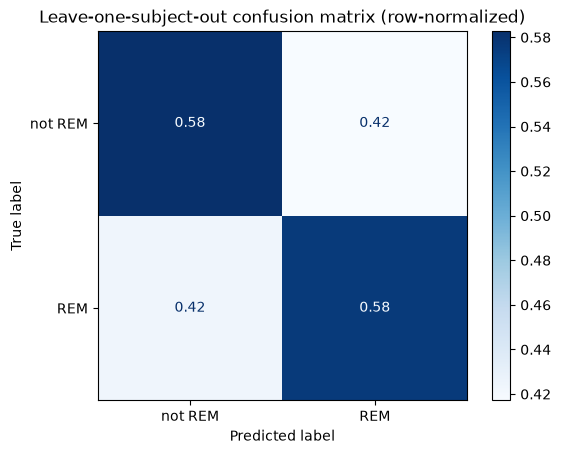

In [6]:
rem_f1_scores, y_true_all, y_pred_all = [], [], []
for train_idx, test_idx in splits.cross_validator().split(X, y, groups=groups):
    m = build_model().fit(X[train_idx], y[train_idx])
    y_pred = m.predict(X[test_idx])
    rem_f1_scores.append(f1_score(y[test_idx], y_pred, pos_label=1, zero_division=0))
    y_true_all.append(y[test_idx]); y_pred_all.append(y_pred)

rem_f1_scores = np.array(rem_f1_scores)
mean = rem_f1_scores.mean()
sem = rem_f1_scores.std(ddof=1) / np.sqrt(rem_f1_scores.size)

y_true_all, y_pred_all = np.concatenate(y_true_all), np.concatenate(y_pred_all)
print(classification_report(y_true_all, y_pred_all, labels=[1], target_names=["REM"], zero_division=0))
print(f"per-subject mean REM F1 (the metric Weco maximizes): "
      f"{mean:.4f} +/- {sem:.4f} SEM  over {rem_f1_scores.size} subjects")
ConfusionMatrixDisplay.from_predictions(
    y_true_all, y_pred_all, display_labels=["not REM", "REM"], normalize="true", cmap="Blues")
plt.title("Leave-one-subject-out confusion matrix (row-normalized)"); plt.show()

## 6. A causal temporal model

A model may use the past, just not the future. This one augments each epoch with a
causal EMA of earlier epochs (reset at each night boundary via `groups`), then
classifies. It declares `fit(X, y, groups)`, trains per night, passes the
look-ahead check, and is scored with the same leave-one-subject-out protocol.

In [7]:
from evaluate import _fit, _predictions_are_causal
from sklearn.ensemble import RandomForestClassifier

class CausalTemporalModel:
    '''RF over each epoch's features augmented with a causal EMA of PAST epochs,
    reset per night via `groups`. Uses only past + present -> real-time.'''
    def __init__(self, alpha=0.1, threshold=0.24):
        self.alpha, self.threshold = alpha, threshold
        self.base = RandomForestClassifier(n_estimators=200, min_samples_leaf=48,
                                           n_jobs=-1, random_state=0)

    def _augment(self, X, groups):
        ema = np.empty_like(X, dtype=float)
        for g in np.unique(groups):                  # never cross a night boundary
            idx = np.where(groups == g)[0]
            acc = X[idx[0]].astype(float)
            for j in idx:                            # causal: past + current only
                acc = self.alpha * X[j] + (1 - self.alpha) * acc
                ema[j] = acc
        return np.hstack([X, ema])

    def fit(self, X, y, groups=None):
        if groups is None:
            groups = np.zeros(len(X), dtype=int)
        self.base.fit(self._augment(X, groups), y)
        self._rem_col = list(self.base.classes_).index(1)
        return self

    def predict(self, X):                            # predict = one night
        Xa = self._augment(X, np.zeros(len(X), dtype=int))
        return (self.base.predict_proba(Xa)[:, self._rem_col] >= self.threshold).astype(int)

# real-time guard on a held-out fold (groups passed to fit via _fit)
tr, te = next(splits.cross_validator().split(X, y, groups=groups))
m = _fit(CausalTemporalModel(), X[tr], y[tr], groups[tr])
print("causal temporal model passes the real-time guard:",
      _predictions_are_causal(m, X[te], m.predict(X[te])))

# leave-one-subject-out, per-subject mean F1 (same protocol as evaluate.py)
scores = []
for tr, te in splits.cross_validator().split(X, y, groups=groups):
    m = _fit(CausalTemporalModel(), X[tr], y[tr], groups[tr])
    scores.append(f1_score(y[te], m.predict(X[te]), pos_label=1, zero_division=0))
scores = np.array(scores)
print(f"causal temporal model: per-subject mean REM F1 = {scores.mean():.4f} +/- "
      f"{scores.std(ddof=1)/np.sqrt(scores.size):.4f}  (RF baseline was 0.3502)")

causal temporal model passes the real-time guard: True


causal temporal model: per-subject mean REM F1 = 0.3504 +/- 0.0292  (RF baseline was 0.3502)


## Summary

The pipeline runs end to end: wearable and PSG signals, causal features, a
look-ahead check, and a per-subject leave-one-subject-out score. This is the
baseline Weco starts from. `weco run` rewrites the model in `module.py` (the
features in `features.py` stay fixed) to raise REM F1, and the look-ahead check
keeps each candidate deployable in real time.